# Credit Card Approval Prediction

This notebook is organized into:

- **Epic 2** — Visualizing and Analysing the Data
- **Epic 3** — Data Pre-processing
- **Epic 4** — Model Building
- **Epic 5** — Application Building

# Epic 2 : Visualizing and Analysing the Data

## Importing the Libraries

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set(style='whitegrid', rc={'figure.figsize': (9, 5)})


## Read the Dataset

In [2]:
app = pd.read_csv('application_record.csv')
credit = pd.read_csv('creditcard.csv')

print('application_record.csv shape:', app.shape)
print('creditcard.csv shape:', credit.shape)
app.head()


application_record.csv shape: (438557, 18)
creditcard.csv shape: (284807, 31)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


## Univariate Analysis

Looking at one variable at a time: how income is distributed, and the spread across the categorical fields the web form actually collects.

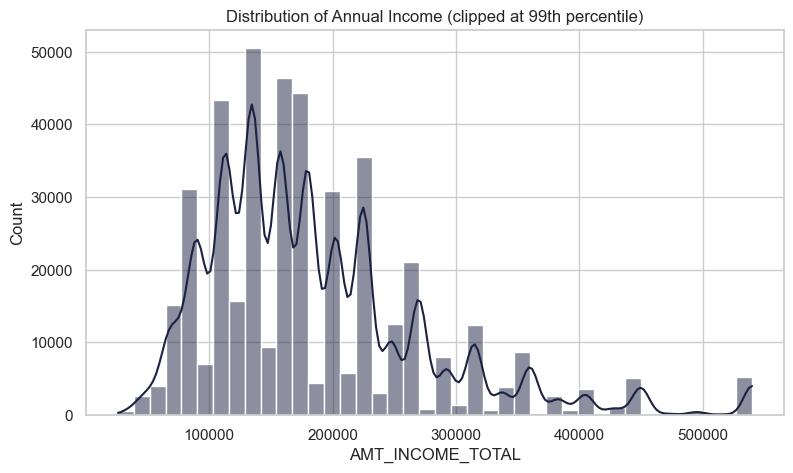

In [3]:
plt.figure()
sns.histplot(app['AMT_INCOME_TOTAL'].clip(upper=app['AMT_INCOME_TOTAL'].quantile(0.99)), bins=40, kde=True, color='#1B2140')
plt.title('Distribution of Annual Income (clipped at 99th percentile)')
plt.xlabel('AMT_INCOME_TOTAL')
plt.show()


C:\Users\sukum\AppData\Local\Temp\ipykernel_23936\1393309081.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NAME_INCOME_TYPE', data=app, order=app['NAME_INCOME_TYPE'].value_counts().index, palette='crest')


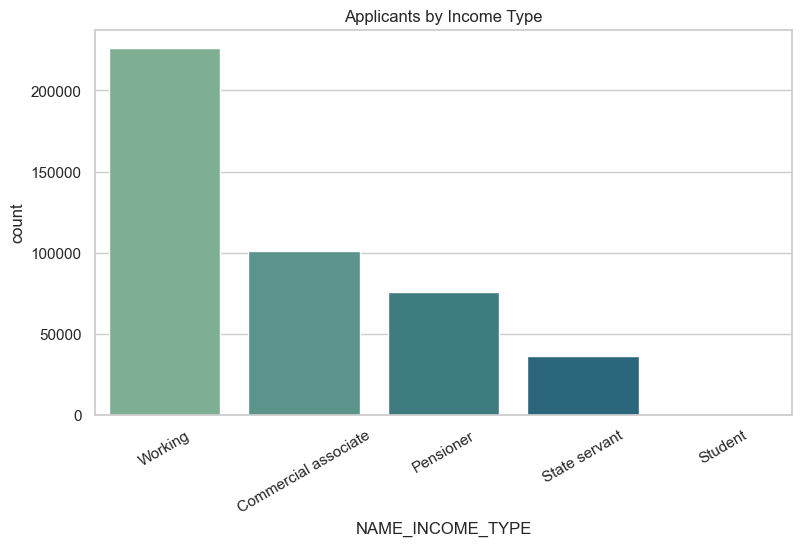

In [4]:
plt.figure()
sns.countplot(x='NAME_INCOME_TYPE', data=app, order=app['NAME_INCOME_TYPE'].value_counts().index, palette='crest')
plt.title('Applicants by Income Type')
plt.xticks(rotation=30)
plt.show()


C:\Users\sukum\AppData\Local\Temp\ipykernel_23936\3663815556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NAME_EDUCATION_TYPE', data=app, order=app['NAME_EDUCATION_TYPE'].value_counts().index, palette='crest')


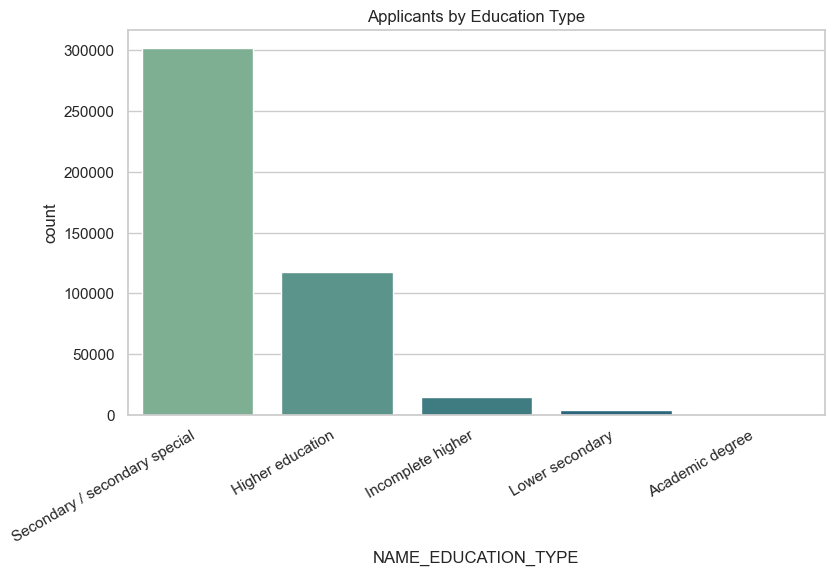

In [5]:
plt.figure()
sns.countplot(x='NAME_EDUCATION_TYPE', data=app, order=app['NAME_EDUCATION_TYPE'].value_counts().index, palette='crest')
plt.title('Applicants by Education Type')
plt.xticks(rotation=30, ha='right')
plt.show()


C:\Users\sukum\AppData\Local\Temp\ipykernel_23936\4105159413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CODE_GENDER', data=app, palette='crest')


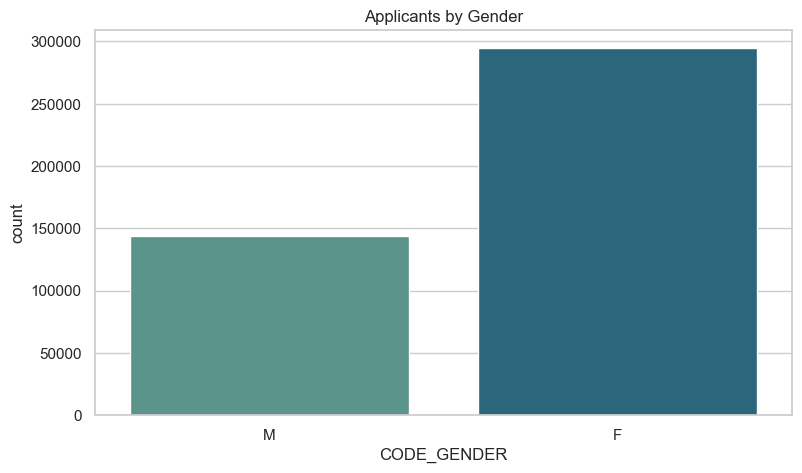

In [6]:
plt.figure()
sns.countplot(x='CODE_GENDER', data=app, palette='crest')
plt.title('Applicants by Gender')
plt.show()


## Multivariate Analysis

How income relates to income type and education, and how the numeric applicant fields correlate with each other.

C:\Users\sukum\AppData\Local\Temp\ipykernel_23936\1891670159.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='NAME_INCOME_TYPE', y='INCOME_CAPPED', data=income_capped, palette='crest')


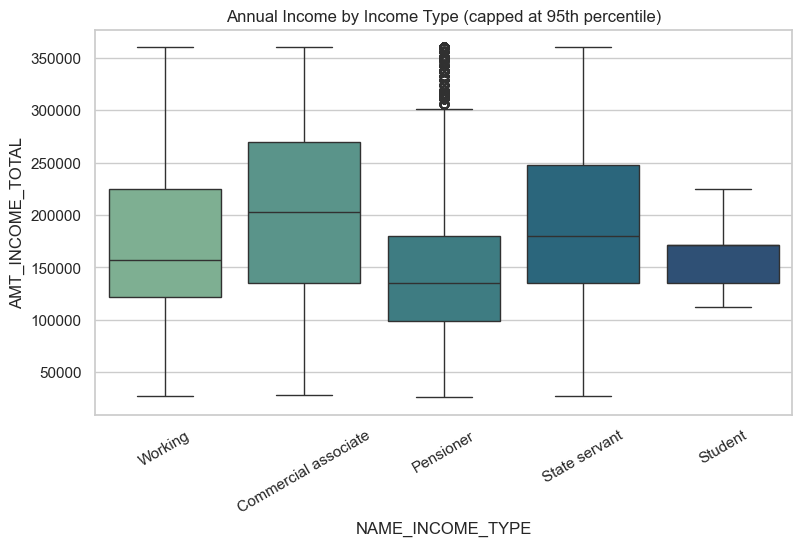

In [7]:
plt.figure()
income_capped = app.assign(INCOME_CAPPED=app['AMT_INCOME_TOTAL'].clip(upper=app['AMT_INCOME_TOTAL'].quantile(0.95)))
sns.boxplot(x='NAME_INCOME_TYPE', y='INCOME_CAPPED', data=income_capped, palette='crest')
plt.title('Annual Income by Income Type (capped at 95th percentile)')
plt.xticks(rotation=30)
plt.ylabel('AMT_INCOME_TOTAL')
plt.show()


C:\Users\sukum\AppData\Local\Temp\ipykernel_23936\3310041195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='NAME_EDUCATION_TYPE', y='INCOME_CAPPED', data=income_capped, palette='crest')


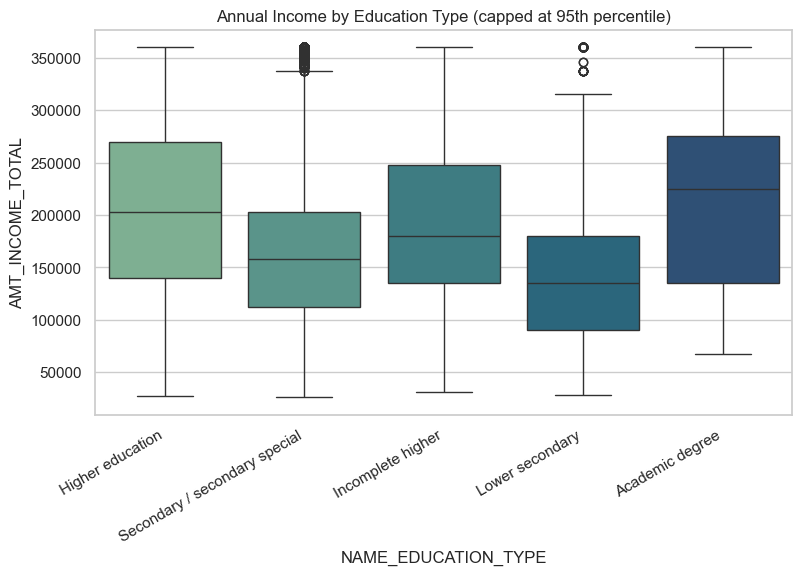

In [8]:
plt.figure()
sns.boxplot(x='NAME_EDUCATION_TYPE', y='INCOME_CAPPED', data=income_capped, palette='crest')
plt.title('Annual Income by Education Type (capped at 95th percentile)')
plt.xticks(rotation=30, ha='right')
plt.ylabel('AMT_INCOME_TOTAL')
plt.show()


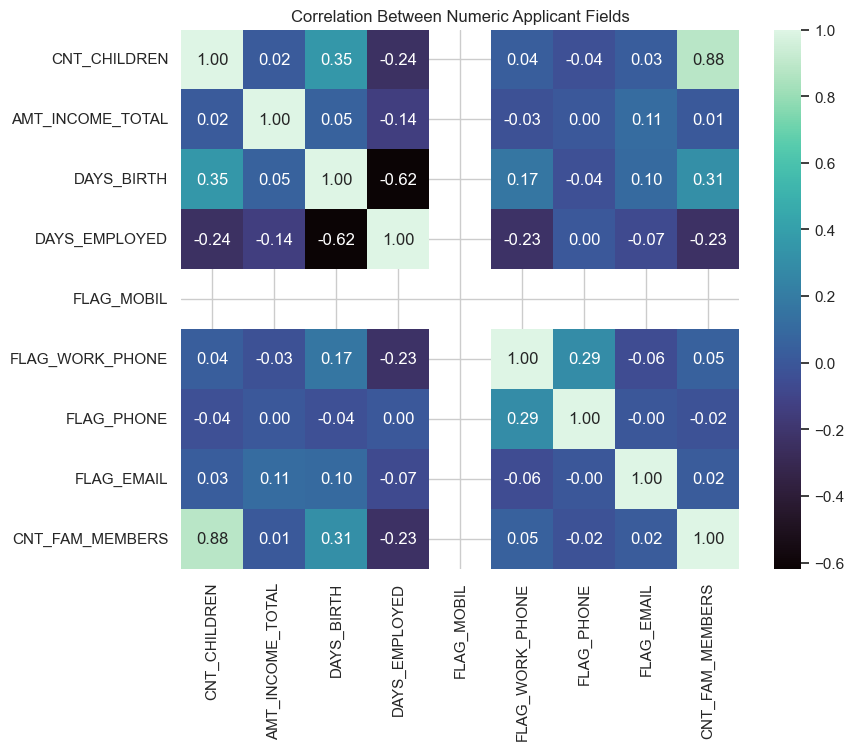

In [9]:
numeric_app = app.select_dtypes(include=['number']).drop(columns=['ID'], errors='ignore')

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_app.corr(), annot=True, fmt='.2f', cmap='mako')
plt.title('Correlation Between Numeric Applicant Fields')
plt.show()


## Descriptive Analysis

In [69]:
app.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0


In [10]:
app.describe(include='object').T


,count,unique,top,freq
CODE_GENDER,438557,2,F,294440
FLAG_OWN_CAR,438557,2,N,275459
FLAG_OWN_REALTY,438557,2,Y,304074
NAME_INCOME_TYPE,438557,5,Working,226104
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821
NAME_FAMILY_STATUS,438557,5,Married,299828
NAME_HOUSING_TYPE,438557,6,House / apartment,393831
OCCUPATION_TYPE,304354,18,Laborers,78240


In [11]:
print('Missing values per column (%):')
print((app.isnull().mean() * 100).round(2).sort_values(ascending=False))


Missing values per column (%):
OCCUPATION_TYPE        30.6
ID                      0.0
CODE_GENDER             0.0
FLAG_OWN_CAR            0.0
CNT_CHILDREN            0.0
FLAG_OWN_REALTY         0.0
NAME_INCOME_TYPE        0.0
NAME_EDUCATION_TYPE     0.0
NAME_FAMILY_STATUS      0.0
AMT_INCOME_TOTAL        0.0
NAME_HOUSING_TYPE       0.0
DAYS_BIRTH              0.0
FLAG_MOBIL              0.0
DAYS_EMPLOYED           0.0
FLAG_WORK_PHONE         0.0
FLAG_PHONE              0.0
FLAG_EMAIL              0.0
CNT_FAM_MEMBERS         0.0
dtype: float64


In [12]:
print(f"Income skew: {app['AMT_INCOME_TOTAL'].skew():.2f}")
print(f"Median annual income: {app['AMT_INCOME_TOTAL'].median():,.0f}")
print(f"Mean annual income: {app['AMT_INCOME_TOTAL'].mean():,.0f}")


Income skew: 8.83
Median annual income: 160,780
Mean annual income: 187,524


# Epic 3 : Data Pre-processing

## Drop Duplicate Features

In [13]:
before = app.shape[0]
app.drop_duplicates(
    subset=[
        'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
        'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
        'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
        'DAYS_EMPLOYED', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'
    ],
    keep='first',
    inplace=True
)
app.reset_index(drop=True, inplace=True)
print(f'Dropped {before - app.shape[0]} duplicate rows -> {app.shape[0]} remaining')


Dropped 348558 duplicate rows -> 89999 remaining


## Handling Missing Values

In [14]:
print('Missing values before handling:')
print(app.isnull().sum().sort_values(ascending=False))

# OCCUPATION_TYPE is the main offender in this dataset; fill with an explicit category
# rather than dropping rows, since we don't use it in the deployed model anyway.
if 'OCCUPATION_TYPE' in app.columns:
    app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].fillna('Unknown')

# For the three fields the app actually uses, missing values are dropped since they
# can't be safely imputed for a categorical dropdown or an income figure.
app.dropna(subset=['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'AMT_INCOME_TOTAL'], inplace=True)
app.reset_index(drop=True, inplace=True)
print('\nMissing values after handling:')
print(app.isnull().sum().sort_values(ascending=False))


Missing values before handling:
OCCUPATION_TYPE        27415
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
CNT_CHILDREN               0
FLAG_OWN_REALTY            0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
AMT_INCOME_TOTAL           0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
FLAG_MOBIL                 0
DAYS_EMPLOYED              0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
CNT_FAM_MEMBERS            0
dtype: int64

Missing values after handling:
ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
O

## Data Cleaning and Merging

In [15]:
shared_key = 'ID' in credit.columns and set(app['ID']).intersection(set(credit['ID'])) if 'ID' in credit.columns else set()
print(f'Rows with a genuinely shared ID between the two files: {len(shared_key) if shared_key else 0}')
print('-> confirms creditcard.csv cannot be merged onto application_record.csv by ID.')

app_features = app[[
    'ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL'
]].copy()

app_features['AGE_YEARS'] = (app_features['DAYS_BIRTH'].abs() / 365.25).round(1)

# DAYS_EMPLOYED uses a documented sentinel (365243, i.e. positive) for pensioners /
# people not currently employed, which would otherwise look like ~1000 years of
# employment. Treat any positive DAYS_EMPLOYED as 0 years employed instead.
app_features['YEARS_EMPLOYED'] = np.where(
    app_features['DAYS_EMPLOYED'] > 0,
    0.0,
    (app_features['DAYS_EMPLOYED'].abs() / 365.25).round(1)
)
app_features.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)


Rows with a genuinely shared ID between the two files: 0
-> confirms creditcard.csv cannot be merged onto application_record.csv by ID.


In [16]:
rng = np.random.default_rng(42)

income_median = app_features['AMT_INCOME_TOTAL'].median()
strong_income_type = {'Working', 'Commercial associate', 'State servant'}
strong_education = {'Higher education', 'Academic degree'}
stable_family = {'Married', 'Civil marriage'}
stable_housing = {'House / apartment', 'Office apartment'}

score = (
    (app_features['AMT_INCOME_TOTAL'] >= income_median).astype(int)
    + app_features['NAME_INCOME_TYPE'].isin(strong_income_type).astype(int)
    + app_features['NAME_EDUCATION_TYPE'].isin(strong_education).astype(int)
    + (app_features['FLAG_OWN_CAR'] == 'Y').astype(int)
    + (app_features['FLAG_OWN_REALTY'] == 'Y').astype(int)
    + (app_features['AGE_YEARS'] >= 25).astype(int)
    + (app_features['YEARS_EMPLOYED'] >= 2).astype(int)
    + app_features['NAME_FAMILY_STATUS'].isin(stable_family).astype(int)
    + app_features['NAME_HOUSING_TYPE'].isin(stable_housing).astype(int)
    - (app_features['CNT_CHILDREN'] >= 4).astype(int)
)

final_df = app_features.copy()
final_df['APPROVED'] = (score >= 5).astype(int)

# flip ~12% of labels at random so the pattern isn't a perfectly clean lookup table
noise_mask = rng.random(len(final_df)) < 0.12
final_df.loc[noise_mask, 'APPROVED'] = 1 - final_df.loc[noise_mask, 'APPROVED']

print(final_df['APPROVED'].value_counts())
final_df.head()


APPROVED
1    66432
0    23567
Name: count, dtype: int64


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,AGE_YEARS,YEARS_EMPLOYED,APPROVED
0,5008804,M,Y,Y,0,Working,Higher education,Civil marriage,Rented apartment,Unknown,2.0,427500.0,32.9,12.4,1
1,5008806,M,Y,Y,0,Working,Secondary / secondary special,Married,House / apartment,Security staff,2.0,112500.0,58.8,3.1,1
2,5008808,F,N,Y,0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,270000.0,52.3,8.4,1
3,5008812,F,N,Y,0,Pensioner,Higher education,Separated,House / apartment,Unknown,1.0,283500.0,61.5,0.0,1
4,5008815,M,Y,Y,0,Working,Higher education,Married,House / apartment,Accountants,2.0,270000.0,46.2,2.1,0


## Feature Engineering

`AGE_YEARS` and `YEARS_EMPLOYED` are derived from `DAYS_BIRTH` / `DAYS_EMPLOYED` above, before the categorical-encoding step below. The deployed app now collects all of the fields used here, so the encoders and feature order match the full web form.


In [17]:
analysis_df = app.copy()
analysis_df['AGE_YEARS'] = (analysis_df['DAYS_BIRTH'].abs() / 365.25).round(1)
analysis_df['YEARS_EMPLOYED'] = (analysis_df['DAYS_EMPLOYED'].abs() / 365.25).round(1)
analysis_df[['AGE_YEARS', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS']].describe()


,AGE_YEARS,YEARS_EMPLOYED,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS
count,89999.000000,89999.000000,8.999900e+04,89999.000000
mean,43.526666,179.203113,1.787189e+05,2.177446
std,11.646779,376.362192,1.024799e+05,0.904875
min,20.500000,0.000000,2.610000e+04,1.000000
25%,33.800000,2.700000,1.125000e+05,2.000000
50%,42.600000,6.300000,1.575000e+05,2.000000
75%,53.200000,15.200000,2.250000e+05,3.000000
max,69.000000,1000.000000,6.750000e+06,20.000000


## Handling Categorical Values

`LabelEncoder`s are fit on the two categorical fields the app actually collects, and saved alongside the models so `app.py` can encode the dropdown selections identically at inference time.

In [18]:
income_type_encoder = LabelEncoder()
education_type_encoder = LabelEncoder()
gender_encoder = LabelEncoder()
own_car_encoder = LabelEncoder()
own_realty_encoder = LabelEncoder()
family_status_encoder = LabelEncoder()
housing_type_encoder = LabelEncoder()
occupation_type_encoder = LabelEncoder()

final_df['INCOME_TYPE_ENC'] = income_type_encoder.fit_transform(final_df['NAME_INCOME_TYPE'])
final_df['EDUCATION_TYPE_ENC'] = education_type_encoder.fit_transform(final_df['NAME_EDUCATION_TYPE'])
final_df['GENDER_ENC'] = gender_encoder.fit_transform(final_df['CODE_GENDER'])
final_df['OWN_CAR_ENC'] = own_car_encoder.fit_transform(final_df['FLAG_OWN_CAR'])
final_df['OWN_REALTY_ENC'] = own_realty_encoder.fit_transform(final_df['FLAG_OWN_REALTY'])
final_df['FAMILY_STATUS_ENC'] = family_status_encoder.fit_transform(final_df['NAME_FAMILY_STATUS'])
final_df['HOUSING_TYPE_ENC'] = housing_type_encoder.fit_transform(final_df['NAME_HOUSING_TYPE'])
final_df['OCCUPATION_TYPE_ENC'] = occupation_type_encoder.fit_transform(final_df['OCCUPATION_TYPE'])

print('Income type classes:', list(income_type_encoder.classes_))
print('Education type classes:', list(education_type_encoder.classes_))
print('Gender classes:', list(gender_encoder.classes_))
print('Own car classes:', list(own_car_encoder.classes_))
print('Own realty classes:', list(own_realty_encoder.classes_))
print('Family status classes:', list(family_status_encoder.classes_))
print('Housing type classes:', list(housing_type_encoder.classes_))
print('Occupation type classes:', list(occupation_type_encoder.classes_))


Income type classes: ['Commercial associate', 'Pensioner', 'State servant', 'Student', 'Working']
Education type classes: ['Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special']
Gender classes: ['F', 'M']
Own car classes: ['N', 'Y']
Own realty classes: ['N', 'Y']
Family status classes: ['Civil marriage', 'Married', 'Separated', 'Single / not married', 'Widow']
Housing type classes: ['Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents']
Occupation type classes: ['Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff', 'Drivers', 'HR staff', 'High skill tech staff', 'IT staff', 'Laborers', 'Low-skill Laborers', 'Managers', 'Medicine staff', 'Private service staff', 'Realty agents', 'Sales staff', 'Secretaries', 'Security staff', 'Unknown', 'Waiters/barmen staff']


# Epic 4 : Model Building

In [19]:
FEATURE_ORDER = [
    'GENDER_ENC', 'OWN_CAR_ENC', 'OWN_REALTY_ENC', 'CNT_CHILDREN',
    'INCOME_TYPE_ENC', 'EDUCATION_TYPE_ENC', 'FAMILY_STATUS_ENC',
    'HOUSING_TYPE_ENC', 'OCCUPATION_TYPE_ENC', 'CNT_FAM_MEMBERS',
    'AGE_YEARS', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL'
]

X = final_df[FEATURE_ORDER]
y = final_df['APPROVED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')


Train size: 71999, Test size: 18000


## Logistic Regression Model

In [20]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))


Accuracy: 0.8262222222222222
              precision    recall  f1-score   support

           0       0.78      0.47      0.58      4713
           1       0.83      0.95      0.89     13287

    accuracy                           0.83     18000
   macro avg       0.81      0.71      0.74     18000
weighted avg       0.82      0.83      0.81     18000



c:\Users\sukum\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Random Forest Model

In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


Accuracy: 0.8713333333333333
              precision    recall  f1-score   support

           0       0.86      0.60      0.71      4713
           1       0.87      0.97      0.92     13287

    accuracy                           0.87     18000
   macro avg       0.87      0.78      0.81     18000
weighted avg       0.87      0.87      0.86     18000



## Decision Tree Model

In [22]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, dt_preds))
print(classification_report(y_test, dt_preds))


Accuracy: 0.7714444444444445
              precision    recall  f1-score   support

           0       0.56      0.59      0.58      4713
           1       0.85      0.83      0.84     13287

    accuracy                           0.77     18000
   macro avg       0.71      0.71      0.71     18000
weighted avg       0.78      0.77      0.77     18000



## Save the Models and Encoders

Everything `app.py` needs at inference time — the three trained models, one `LabelEncoder` per categorical field the form collects, and the exact feature order used during training — is bundled into a single `model.pkl`.


In [23]:
bundle = {
    'models': {
        'logistic_regression': lr_model,
        'random_forest': rf_model,
        'decision_tree': dt_model,
    },
    'gender_encoder': gender_encoder,
    'own_car_encoder': own_car_encoder,
    'own_realty_encoder': own_realty_encoder,
    'income_type_encoder': income_type_encoder,
    'education_type_encoder': education_type_encoder,
    'family_status_encoder': family_status_encoder,
    'housing_type_encoder': housing_type_encoder,
    'occupation_type_encoder': occupation_type_encoder,
    'feature_order': FEATURE_ORDER,
}

with open('model.pkl', 'wb') as file:
    pickle.dump(bundle, file)

print('Saved models + encoders + feature order to model.pkl')


Saved models + encoders + feature order to model.pkl
